# Análise meus livros lidos

Este projeto tem como objetivo analisar meus hábitos de leitura a partir do histórico de 54 livros lidos (Até dia 11/08/2026)

A análise busca identificar padrões relacionados ao volume de leitura, gêneros, autores, avaliação e ritmo de leitura ao longo do tempo.

Perguntas que quero responder
- Como meu volume de leitura evoluiu ao longo dos anos?
- Quais gêneros leio mais?
- Quais autores aparecem com maior frequência?
- Como meu ritmo de leitura evoluiu?
- Existe relação entre tamanho do livro e tempo de leitura?
- Minha avaliação varia de acordo com gênero ou outras características?

# Preparação

## Import dos dados

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv("/content/lidos.csv", sep=";", encoding="latin1")

In [65]:
df.head()

,isbn,titulo,autor,paginas,ano_publicacao,genero,subgenero,tipo,pais_autor,nome_serie,num_serie,formato,avaliacao,data_inicio,data_termino,preco,data_compra,tipo_aquisicao,Status
0,9788581220307,Jogos Vorazes,Suzanne Collins,393,2008,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Jogos Vorazes,1.0,Ebook,5.0,2022-10-13,2022-10-17,NaN,NaN,Kindle,concluido
1,9788580417661,Origem,Dan Brown,432,2017,Suspense,Investigativo,Ficção,Estados Unidos,NaN,NaN,Ebook,5.0,2021-06-13,2021-06-27,NaN,NaN,Kindle,concluido
2,9788576832478,Mazer Runner - Correr ou morrer,James Dashner,428,2009,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Mazer Runner,1.0,Ebook,5.0,2020-09-20,2020-09-24,NaN,NaN,Kindle,concluido
3,9788599296677,Ponto de Impacto,Dan Brown,400,1993,Suspense,Policial,Ficção,Estados Unidos,NaN,NaN,Ebook,5.0,2021-04-22,2021-05-08,NaN,NaN,Kindle,concluido
4,9786555320749,Jogos Vorazes - Em Chamas,Suzanne Collins,416,2009,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Jogos Vorazes,2.0,Ebook,5.0,2026-02-02,2026-02-12,NaN,NaN,Kindle,concluido


## Estrutura

In [66]:
df.shape

(54, 19)

A amostra de dados possui 54 livros.

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn            54 non-null     object 
 1   titulo          54 non-null     object 
 2   autor           54 non-null     object 
 3   paginas         54 non-null     int64  
 4   ano_publicacao  54 non-null     int64  
 5   genero          54 non-null     object 
 6   subgenero       54 non-null     object 
 7   tipo            54 non-null     object 
 8   pais_autor      54 non-null     object 
 9   nome_serie      7 non-null      object 
 10  num_serie       7 non-null      float64
 11  formato         54 non-null     object 
 12  avaliacao       54 non-null     float64
 13  data_inicio     54 non-null     object 
 14  data_termino    54 non-null     object 
 15  preco           10 non-null     object 
 16  data_compra     10 non-null     object 
 17  tipo_aquisicao  54 non-null     objec

In [68]:
df.describe()

,paginas,ano_publicacao,num_serie,avaliacao
count,54.000000,54.000000,7.000000,54.000000
mean,297.277778,1970.277778,1.571429,3.981481
std,108.442562,132.273076,0.786796,0.752123
min,64.000000,1087.000000,1.000000,1.500000
25%,242.250000,1972.750000,1.000000,3.500000
50%,310.500000,2009.000000,1.000000,4.000000
75%,377.750000,2018.750000,2.000000,4.500000
max,544.000000,2024.000000,3.000000,5.000000


Esta análise permite identificar algumas características iniciais do conjunto de dados e também possíveis problemas de qualidade. O dataset possui 54 livros, com média de 297 páginas e avaliação média de aproximadamente 3,98.

Entre os valores apresentados, destaca-se o ano mínimo de publicação de 1087, enquanto o valor máximo é 2024. Esse valor mínimo é provavelmente resultado de um erro de preenchimento, sendo necessário verificar o registro correspondente e corrigi-lo antes de prosseguir com as análises relacionadas ao ano de publicação.

In [69]:
df.isna().sum()

,0
isbn,0
titulo,0
autor,0
paginas,0
ano_publicacao,0
genero,0
subgenero,0
tipo,0
pais_autor,0
nome_serie,47


A análise de valores ausentes mostra que a maior parte das colunas está completamente preenchida. As exceções são nome_serie, num_serie, preco e data_compra.

As colunas **nome_serie** e **num_serie** possuem 47 valores ausentes, correspondentes aos livros que não fazem parte de uma série. Portanto, nesse caso, os valores ausentes são esperados e não representam necessariamente um problema de qualidade dos dados.

As colunas **preco** e **data_compra** possuem 44 valores ausentes. Esses valores serão investigados considerando também a coluna tipo_aquisicao, para verificar se a ausência está relacionada à forma como o livro foi adquirido, como presentes ou outras formas de aquisição em que essas informações não se aplicam.

In [70]:
df.duplicated().sum()

np.int64(0)

A análise de valores duplicados mostra que não existem colunas duplicadas no conjunto de dados.

## Limpeza/correção dos dados

Conversão para datetime

In [71]:
date_cols = ["data_inicio", "data_termino", "data_compra"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

As colunas de data foram convertidas para o formato datetime para permitir análises temporais e cálculo do período de leitura.

Ajuste coluna preço

In [72]:
df["preco"] = (
    df["preco"]
    .str.replace("R$", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
    .astype(float)
)

A coluna de preço foi convertida para aceitar os formatos diferentes que podem vir.

Vamos identificar a inconsistência que foi identificada no ano de publicação durante a análise descritiva.

In [73]:
df.loc[df["ano_publicacao"] < 1500, ["titulo", "autor", "ano_publicacao"]]

,titulo,autor,ano_publicacao
42,Misery,Stephen King,1087


O valor correto para o livro identificado com ano de publicação incorreto, é 1987. Será corrigido para as análises que irão utilizar o ano de publicação.

In [74]:
df.loc[df["titulo"] == "Misery", "ano_publicacao"] = 1987

In [75]:
df.loc[df["titulo"] == "Misery", ["titulo", "autor", "ano_publicacao"]]

,titulo,autor,ano_publicacao
42,Misery,Stephen King,1987


In [76]:
df["ano_publicacao"].min()

1818

O ano de 2023 não possui nenhuma leitura, então será identificado como 0 livros lidos. Para isso será criado uma variável "anos", para guardar todos os anos entre o primeiro livro concluído e o último

In [77]:
anos = range(
    df["data_termino"].dt.year.min(),
    df["data_termino"].dt.year.max() + 1
)

## Novas colunas

Criação da coluna dias_leitura, que calcula quandos dias se passaram entre a data de início e término da leitura. (Se o livro começou e terminou no mesmo dia conta como 1)

Não são necessáriamente os dias lidos, pois pode ter ocorrido pausas sem leitura, e sim a data que foi iniciado o livro e a data que foi concluído.

In [78]:
df["dias_de_leitura"] = (
    df["data_termino"] - df["data_inicio"]
).dt.days + 1

Criação da coluna paginas_por_dia, que cálcula quanta páginas em média foram lidas por dia.

In [79]:
df["paginas_por_dia"] = (
    df["paginas"] / df["dias_de_leitura"]
)

Criação da colina ano_leitura, para extrair o ano em que a leitura foi concluída.

In [80]:
df["ano_leitura"] = df["data_termino"].dt.year

## Conjunto de dados pronto para a análise:

In [81]:
df.head()

,isbn,titulo,autor,paginas,ano_publicacao,genero,subgenero,tipo,pais_autor,nome_serie,...,avaliacao,data_inicio,data_termino,preco,data_compra,tipo_aquisicao,Status,dias_de_leitura,paginas_por_dia,ano_leitura
0,9788581220307,Jogos Vorazes,Suzanne Collins,393,2008,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Jogos Vorazes,...,5.0,2022-10-13,2022-10-17,NaN,NaT,Kindle,concluido,5,78.600000,2022
1,9788580417661,Origem,Dan Brown,432,2017,Suspense,Investigativo,Ficção,Estados Unidos,NaN,...,5.0,2021-06-13,2021-06-27,NaN,NaT,Kindle,concluido,15,28.800000,2021
2,9788576832478,Mazer Runner - Correr ou morrer,James Dashner,428,2009,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Mazer Runner,...,5.0,2020-09-20,2020-09-24,NaN,NaT,Kindle,concluido,5,85.600000,2020
3,9788599296677,Ponto de Impacto,Dan Brown,400,1993,Suspense,Policial,Ficção,Estados Unidos,NaN,...,5.0,2021-04-22,2021-05-08,NaN,NaT,Kindle,concluido,17,23.529412,2021
4,9786555320749,Jogos Vorazes - Em Chamas,Suzanne Collins,416,2009,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Jogos Vorazes,...,5.0,2026-02-02,2026-02-12,NaN,NaT,Kindle,concluido,11,37.818182,2026


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   isbn             54 non-null     object        
 1   titulo           54 non-null     object        
 2   autor            54 non-null     object        
 3   paginas          54 non-null     int64         
 4   ano_publicacao   54 non-null     int64         
 5   genero           54 non-null     object        
 6   subgenero        54 non-null     object        
 7   tipo             54 non-null     object        
 8   pais_autor       54 non-null     object        
 9   nome_serie       7 non-null      object        
 10  num_serie        7 non-null      float64       
 11  formato          54 non-null     object        
 12  avaliacao        54 non-null     float64       
 13  data_inicio      54 non-null     datetime64[ns]
 14  data_termino     54 non-null     datetime64[

## Exportação dos dados tratados para o Power BI


In [85]:
df.to_csv("data/book_analytics.csv", index=False)

# Análise

## 1 - Evolução dos Hábitos de Leitura

### Quantidade de livros por ano

Como a quantidade de livros concluídos mudou ao longo dos anos?

In [25]:
livros_por_ano = (
    df.groupby(df["ano_leitura"])["titulo"]
      .count()
      .reindex(anos, fill_value=0)
)

livros_por_ano

,titulo
ano_leitura,
2016,1
2017,1
2018,2
2019,1
2020,3
2021,9
2022,3
2023,0
2024,7


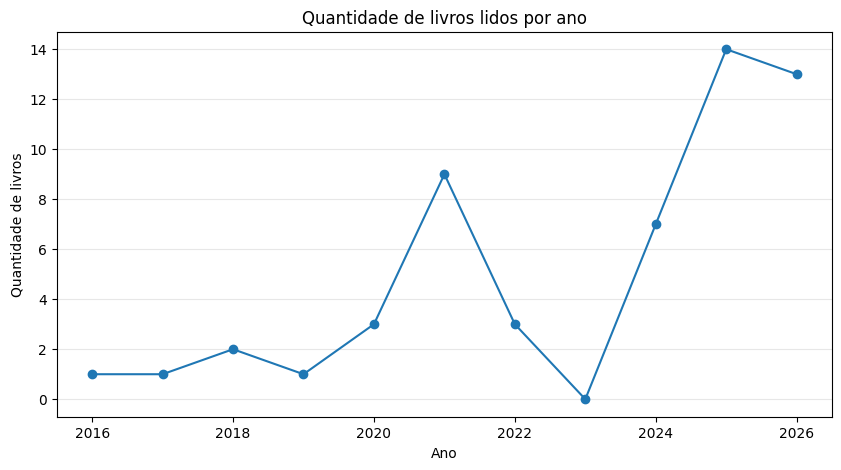

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    livros_por_ano.index,
    livros_por_ano.values,
    marker="o"
)

plt.xlabel("Ano")
plt.ylabel("Quantidade de livros")
plt.title("Quantidade de livros lidos por ano")
plt.grid(axis="y", alpha=0.3)

plt.show()

A quantidade de livros lidos apresentou um crescimento ao longo dos anos, com uma pausa na leitura no ano de 2023 e com um maior volume de leitura em 2025.
Esse resultado indica um aumento no número de livros concluídos, porém a quantidade de livros isoladamente não representa o volume total de leitura, já que os livros possuem diferentes quantidades de páginas.

### Quantidade de páginas por ano

Como a quantidade de páginas concluídas mudou ao longo dos anos?

In [26]:
paginas_por_ano = (
    df.groupby(df["ano_leitura"])["paginas"]
      .sum()
      .reindex(anos, fill_value=0)
)

paginas_por_ano

,paginas
ano_leitura,
2016,310
2017,304
2018,669
2019,272
2020,985
2021,2181
2022,1065
2023,0
2024,2439


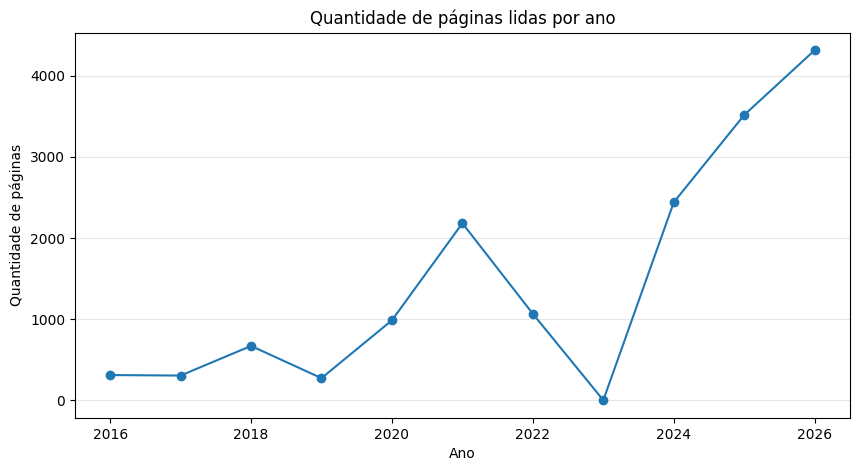

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    paginas_por_ano.index,
    paginas_por_ano.values,
    marker="o"
)

plt.xlabel("Ano")
plt.ylabel("Quantidade de páginas")
plt.title("Quantidade de páginas lidas por ano")
plt.grid(axis="y", alpha=0.3)

plt.show()

A quantidade de páginas lidas no ano também apresentou um crescimento ao longo dos anos e com uma pausa na leitura no ano de 2023. Porém teve um maior volume no ano de 2026, indicando que mesmo com menos livros lidos até a data da amostra, a quantidade de páginas foi maior.

### Evolução do volume de leitura

In [27]:
leitura_por_ano = (
    df.groupby(df["ano_leitura"])
      .agg(
          livros_lidos=("titulo", "count"),
          paginas_lidas=("paginas", "sum")
      )
      .reindex(anos, fill_value=0)
)

leitura_por_ano

,livros_lidos,paginas_lidas
ano_leitura,,
2016,1,310
2017,1,304
2018,2,669
2019,1,272
2020,3,985
2021,9,2181
2022,3,1065
2023,0,0
2024,7,2439


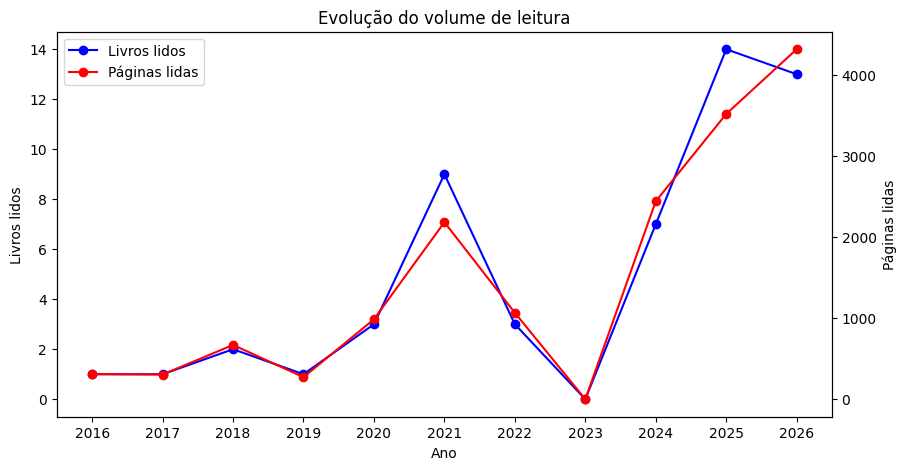

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    leitura_por_ano.index,
    leitura_por_ano["livros_lidos"],
    marker="o",
    color="blue",
    label="Livros lidos"
)

ax1.set_xlabel("Ano")
ax1.set_ylabel("Livros lidos")
ax1.set_xticks(leitura_por_ano.index)

ax2 = ax1.twinx()

ax2.plot(
    leitura_por_ano.index,
    leitura_por_ano["paginas_lidas"],
    marker="o",
    color="red",
    label="Páginas lidas"
)

ax2.set_ylabel("Páginas lidas")

linhas = ax1.lines + ax2.lines
labels = [linha.get_label() for linha in linhas]

ax1.legend(linhas, labels, loc="upper left")

plt.title("Evolução do volume de leitura")
plt.show()

A quantidade de páginas lidas apresenta uma tendência semelhante à quantidade de livros concluídos ao longo dos anos. No entanto, as duas métricas não evoluem de forma proporcional: em alguns períodos, o número de livros aumenta sem um crescimento equivalente no número de páginas, e vice-versa. Isso indica que a quantidade de livros concluídos, isoladamente, não representa completamente o volume de leitura.

### Evolução da velocidade de leitura

Como a velocidade de leitura evoluiu ao longo dos anos?

In [28]:
velocidade_leitura_por_ano = (
    df.groupby(df["ano_leitura"])
      .agg(
          paginas_por_dia=("paginas_por_dia", "mean")
      )
      .reindex(anos, fill_value=0)
)

velocidade_leitura_por_ano

,paginas_por_dia
ano_leitura,
2016,1.448598
2017,1.420561
2018,6.118413
2019,9.714286
2020,47.196212
2021,41.899760
2022,36.380814
2023,0.000000
2024,38.394035


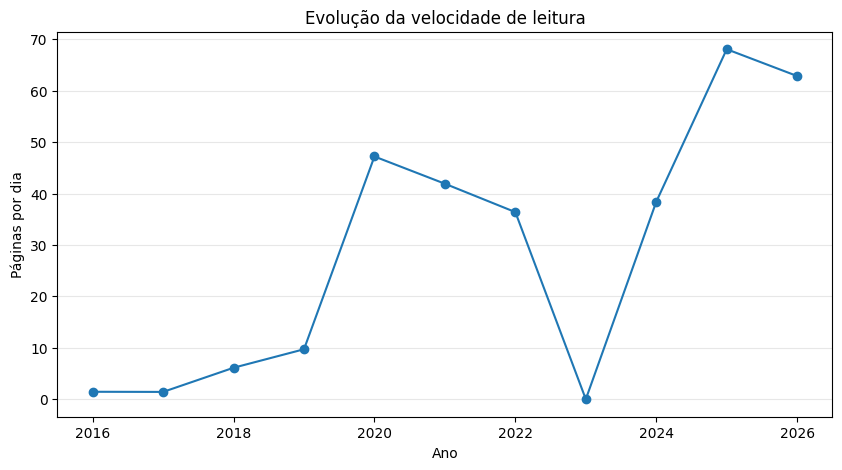

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    velocidade_leitura_por_ano.index,
    velocidade_leitura_por_ano["paginas_por_dia"],
    marker="o"
)

plt.xlabel("Ano")
plt.ylabel("Páginas por dia")
plt.title("Evolução da velocidade de leitura")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [29]:
ritmo_por_ano = (
    df.groupby(df["ano_leitura"])["paginas_por_dia"]
      .agg(["count", "mean", "median"])
)

ritmo_por_ano

,count,mean,median
ano_leitura,,,
2016,1,1.448598,1.448598
2017,1,1.420561,1.420561
2018,2,6.118413,6.118413
2019,1,9.714286,9.714286
2020,3,47.196212,36.363636
2021,9,41.899760,28.800000
2022,3,36.380814,15.304348
2024,7,38.394035,33.090909
2025,14,68.054505,55.785714


A velocidade média de leitura apresentou queda entre 2020 e 2022, seguida de uma recuperação a partir de 2024. O maior aumento ocorreu em 2025, quando a média passou de 38,4 para 68,1 páginas por dia. Em 2026, o ritmo permaneceu elevado, com média de 62,8 páginas por dia. A mediana apresenta comportamento semelhante, reforçando que o aumento observado nos anos mais recentes não está concentrado apenas em alguns livros.

### Meses com maior volume de leitura

Existem alguns meses no ano em que leio mais? Ou leio menos?

In [ ]:
meses = {
    1: "Janeiro",
    2: "Fevereiro",
    3: "Março",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
}

meses_leitura = (
    df.groupby(df["data_termino"].dt.month)["titulo"]
      .count()
      .reindex(range(1, 13), fill_value=0)
)

meses_leitura.index = meses_leitura.index.map(meses)

meses_leitura

,titulo
data_termino,
Janeiro,5
Fevereiro,4
Março,2
Abril,9
Maio,6
Junho,3
Julho,4
Agosto,5
Setembro,3


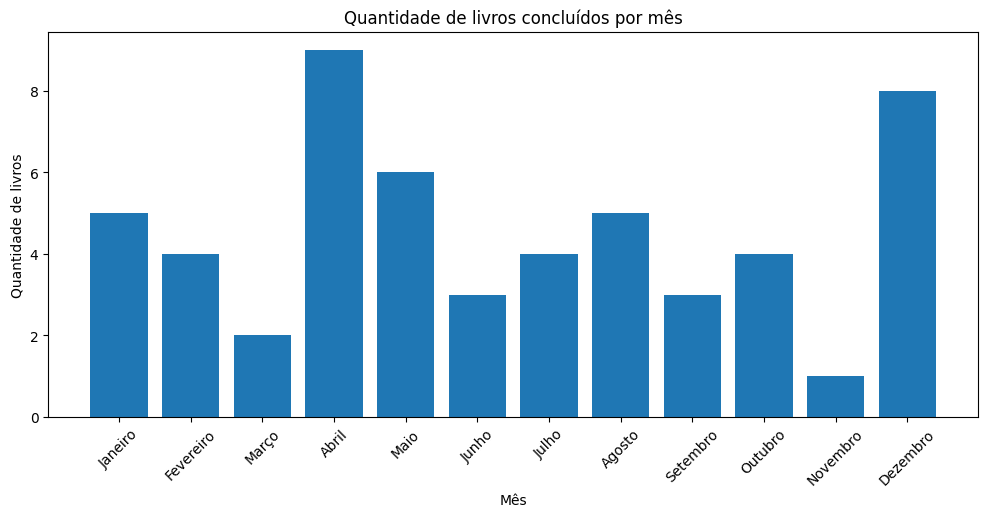

In [ ]:
plt.figure(figsize=(12, 5))

plt.bar(meses_leitura.index, meses_leitura.values)

plt.xlabel("Mês")
plt.ylabel("Quantidade de livros")
plt.title("Quantidade de livros concluídos por mês")

plt.xticks(rotation=45)
plt.show()

A quantidade de livros concluídos varia consideravelmente ao longo dos meses. Abril apresentou o maior volume de leituras, com 9 livros concluídos, seguido por dezembro, com 8. Novembro apresentou o menor volume, com apenas 1 livro. Apesar das diferenças observadas, não é possível identificar um padrão sazonal claro apenas com os dados disponíveis.

### Conclusão

Ao longo do período analisado, observa-se uma evolução no volume e no ritmo
de leitura, principalmente a partir de 2024. 2023 representa uma interrupção
no histórico, sem livros concluídos. Nos anos mais recentes, houve aumento
tanto na quantidade de livros e páginas lidas quanto na velocidade média de
leitura. Apesar das variações mensais, não foi identificado um padrão sazonal
claro no volume de livros concluídos.

## 2 -Perfil de leitura

### Distribuição por gênero

Qual gênero é mais lido?

In [ ]:
generos_leitura = (
    df.groupby("genero")["titulo"]
      .count()
      .sort_values(ascending=False)
)

generos_leitura

,titulo
genero,
Suspense,19
Ficção Cientifica,14
Fantasia,6
Terror,6
Desenvolvimento Pessoal,4
Ficção,2
Biografia,1
Drama,1
Romance,1


Text(0.5, 1.0, 'Quantidade de livros por gênero')

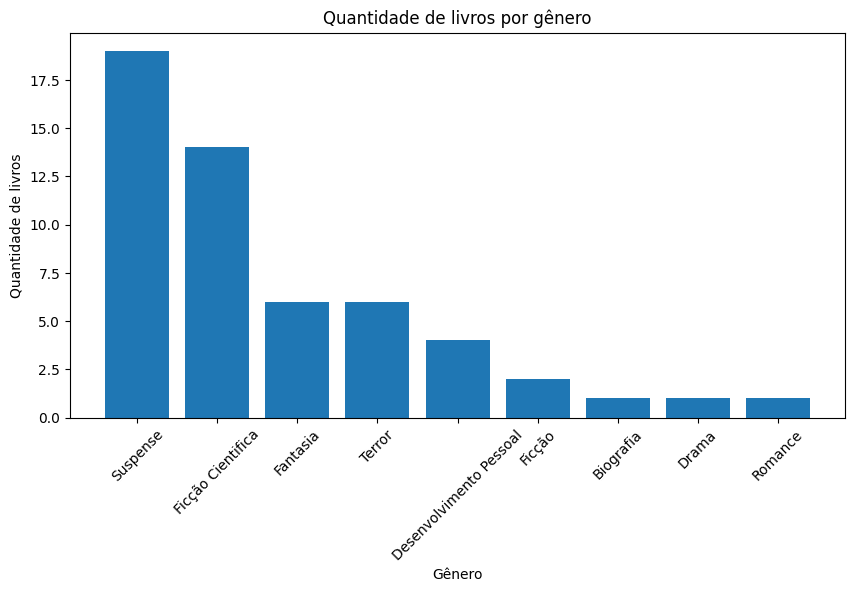

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(generos_leitura.index, generos_leitura.values)

plt.xlabel("Gênero")
plt.xticks(rotation=45)
plt.ylabel("Quantidade de livros")
plt.title("Quantidade de livros por gênero")

Os gêneros mais lidos são Suspense e Ficção Ciêntifica, enquanto Biografia, Drama e Romance possuem menos livros liddos com apenas 1 de cada.

### Ficção x não ficção

Os tipos de livro mais lidos são ficção ou não ficção?

In [ ]:
tipo_livro = (
    df.groupby("tipo")["titulo"]
      .count()
      .sort_values(ascending=False)
)

tipo_livro

,titulo
tipo,
Ficção,49
Não Ficção,5


Text(0.5, 1.0, 'Quantidade de livros por tipo')

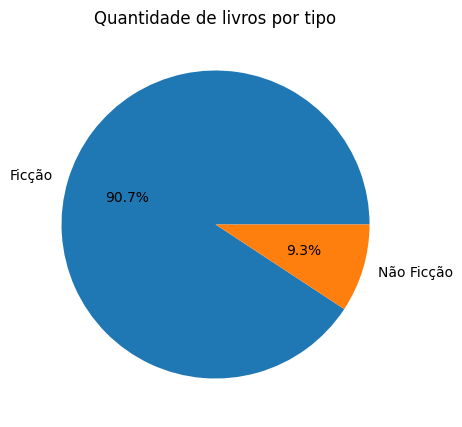

In [ ]:
plt.figure(figsize=(10, 5))

plt.pie(
    tipo_livro.values,
    labels=tipo_livro.index,
    autopct="%1.1f%%"
)

plt.title("Quantidade de livros por tipo")

A leitura é fortemente concentrada em livros de Ficção, que representam 90,7% dos livros concluídos, enquanto a Não Ficção corresponde aos 9,3% restantes.

### Autores mais lidos

Quais os autores mais lidos?

In [ ]:
autores_leitura = (
    df.groupby("autor")["titulo"]
      .count()
      .sort_values(ascending=False)
      .head(10)
)

autores_leitura

,titulo
autor,
Raphael Montes,6
James Dashner,3
Stephen King,3
Dan Brown,2
Blake Crouch,2
Neil Gaiman,2
Suzanne Collins,2
Júlio Verne,2
Freida McFadden,2


Text(0.5, 1.0, 'Quantidade de livros por autor')

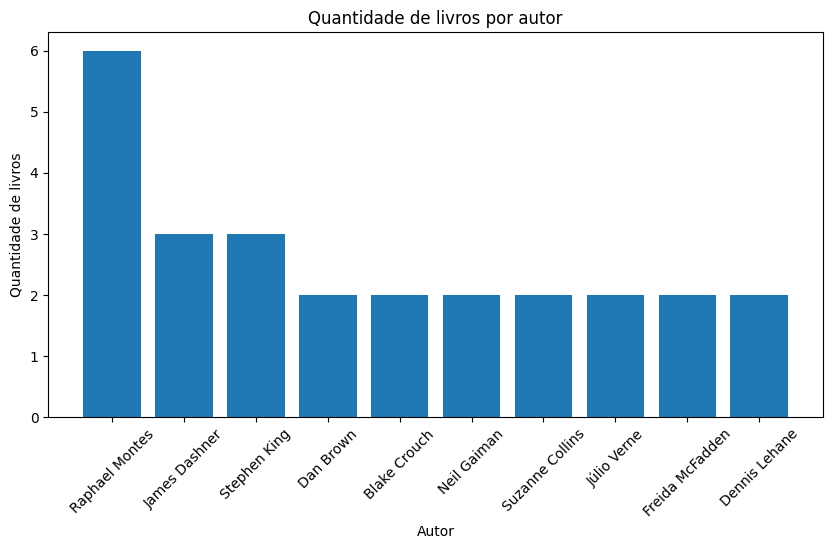

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(autores_leitura.index, autores_leitura.values)

plt.xlabel("Autor")
plt.xticks(rotation=45)
plt.ylabel("Quantidade de livros")
plt.title("Quantidade de livros por autor")

O autor mais lido é Raphael Montes, seguido de James Dashner e Stephen King.

### Séries

Quais e quantos livros de uma série foram lidos?

In [ ]:
series_leitura = (
    df.groupby("nome_serie")["titulo"]
      .count()
      .sort_values(ascending=False)
)

series_leitura

,titulo
nome_serie,
Mazer Runner,3
Jogos Vorazes,2
Harry Potter,1
A Empregada,1


Dentre as séries lidas, apenas Maze Runner teve a trilogia lida completa, enquanto nas outras, a série não foi terminada.

### Formato dos livros

Qual a distribuição entre livros lidos no Kindle x Fisico

In [ ]:
formato_lido = (
    df.groupby("formato")["titulo"]
      .count()
)

formato_lido

,titulo
formato,
Ebook,40
Fisico,14


Text(0.5, 1.0, 'Quantidade de livros por formato')

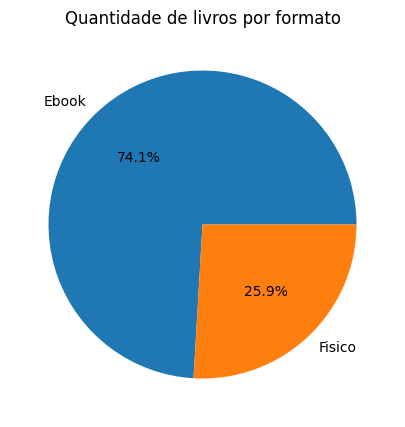

In [ ]:
plt.figure(figsize=(10, 5))

plt.pie(
    formato_lido.values,
    labels=formato_lido.index,
    autopct="%1.1f%%"
)

plt.title("Quantidade de livros por formato")

O formato mais lido é no Ebook, com 74,1% dos livros.

### País do autor

Quais os países dos autores mais lidos?

In [ ]:
pais_autor = (
    df.groupby("pais_autor")["titulo"]
      .count()
      .sort_values(ascending=False)
      .head(10)
)

pais_autor

,titulo
pais_autor,
Estados Unidos,31
Reino Unido,9
Brasil,7
França,3
Chipre,1
Canadá,1
República Tcheca,1
Russia,1


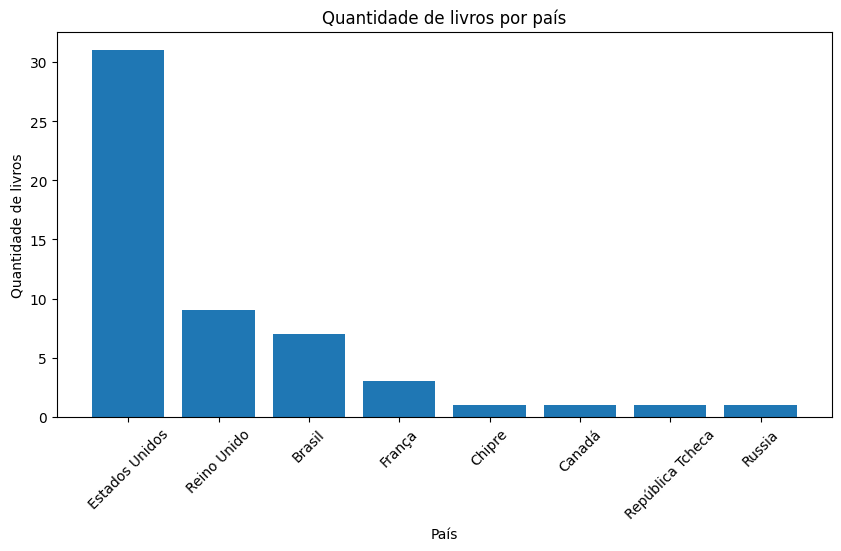

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(pais_autor.index, pais_autor.values)

plt.xlabel("País")
plt.xticks(rotation=45)
plt.ylabel("Quantidade de livros")
plt.title("Quantidade de livros por país")

plt.show()

Os países dos autores, mais lidos, são Estados Unidos (contando com 30 Livros) seguido por Reino Unido e Brasil.

### Ano de publicação dos livros

Os livros lidos estão mais concentrados em livros novos ou antigos?

In [ ]:
decada_publicacao = ((df['ano_publicacao'] // 10) * 10).value_counts().sort_index()

decada_publicacao

,count
ano_publicacao,
1810,1
1840,1
1860,1
1870,1
1880,1
1910,1
1920,1
1930,1
1940,2


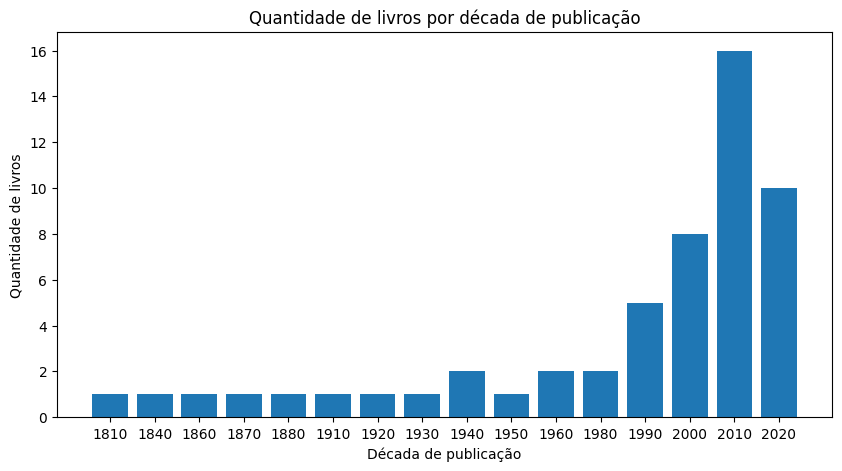

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(decada_publicacao.index.astype(str), decada_publicacao.values)

plt.xlabel("Década de publicação")
plt.ylabel("Quantidade de livros")
plt.title("Quantidade de livros por década de publicação")

plt.show()

A leitura apresenta uma ampla distribuição ao longo das décadas, com livros publicados desde 1810. Entretanto, há uma concentração maior de obras mais recentes, especialmente a partir da década de 1990, com o pico na década de 2010, que reúne 16 livros.

### **Conclusão**: O perfil de leitura é predominantemente voltado à ficção, com forte concentração em Suspense e Ficção Científica. O consumo ocorre principalmente em formato digital e é marcado pela preferência por autores e obras contemporâneas, embora exista uma diversidade significativa de períodos de publicação.

## 3 - Ritmo e comportamento de leitura

### Tempo para concluir um livro

In [ ]:
df['dias_de_leitura'].describe()

,dias_de_leitura
count,54.000000
mean,22.185185
std,41.972171
min,1.000000
25%,4.250000
50%,8.500000
75%,22.750000
max,214.000000


In [ ]:
media_dias = df['dias_de_leitura'].mean()

mediana_dias = df['dias_de_leitura'].median()

print(f"Média de dias para concluir um livro: {media_dias:.1f} dias")

print(f"Mediana de dias para concluir um livro: {mediana_dias:.1f} dias")

Média de dias para concluir um livro: 22.2 dias
Mediana de dias para concluir um livro: 8.5 dias


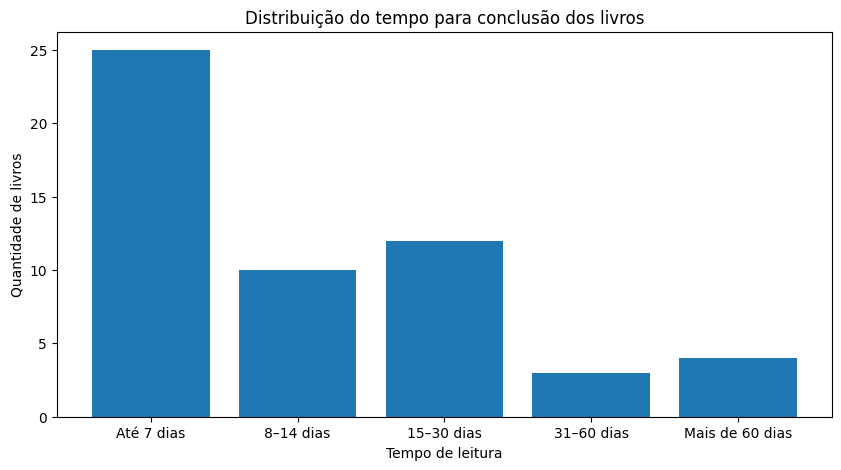

In [ ]:
faixas = pd.cut(
    df['dias_de_leitura'],
    bins=[0, 7, 14, 30, 60, float('inf')],
    labels=['Até 7 dias', '8–14 dias', '15–30 dias', '31–60 dias', 'Mais de 60 dias']
)

tempo_leitura = faixas.value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(tempo_leitura.index, tempo_leitura.values)

plt.xlabel("Tempo de leitura")
plt.ylabel("Quantidade de livros")
plt.title("Distribuição do tempo para conclusão dos livros")

plt.show()

Apesar da média de 22,2 dias para concluir um livro, metade dos livros foi concluída em até 8,5 dias. A diferença entre média e mediana indica que alguns livros com períodos de leitura mais longos elevam significativamente a média.

### Tamanho do livro x tempo de leitura

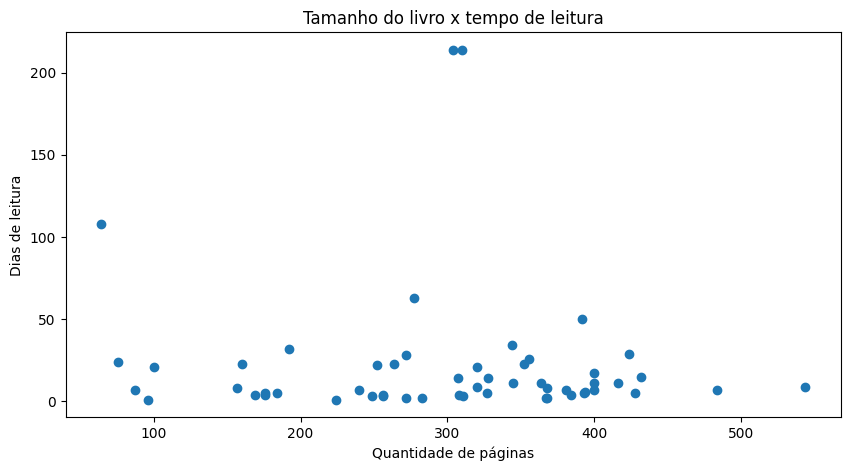

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(df['paginas'], df['dias_de_leitura'])

plt.xlabel("Quantidade de páginas")
plt.ylabel("Dias de leitura")
plt.title("Tamanho do livro x tempo de leitura")

plt.show()

In [ ]:
correlacao = df['paginas'].corr(df['dias_de_leitura'])

print(f"Correlação: {correlacao:.2f}")

Correlação: -0.07


A análise indica uma correlação muito fraca entre o número de páginas e o tempo de leitura, com coeficiente de -0,07. Isso sugere que, na minha amostra, o tamanho do livro não é um fator relevante para determinar o tempo necessário para sua conclusão.

### Tamanho do livro x páginas/dia

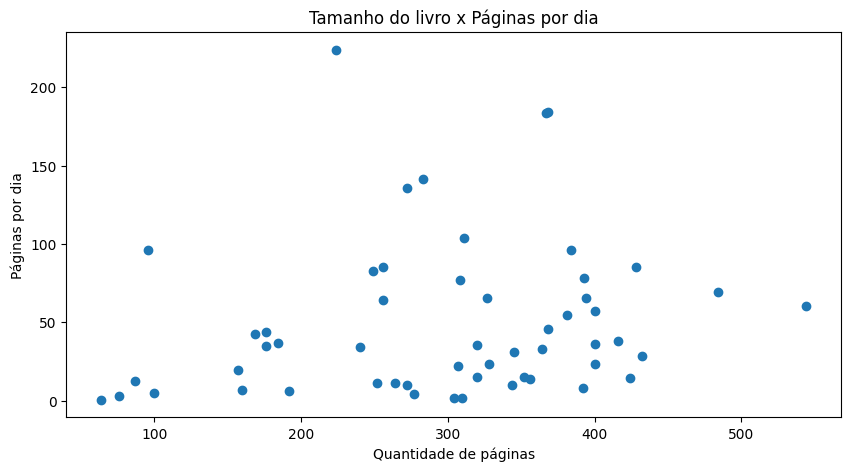

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(df['paginas'], df['paginas_por_dia'])

plt.xlabel("Quantidade de páginas")
plt.ylabel("Páginas por dia")
plt.title("Tamanho do livro x Páginas por dia")

plt.show()

In [ ]:
correlacao = df['paginas'].corr(df['paginas_por_dia'])

print(f"Correlação: {correlacao:.2f}")

Correlação: 0.17


A análise apresentou uma correlação positiva fraca (0,17) entre o número de páginas do livro e a quantidade de páginas lidas por dia. Isso indica que o tamanho do livro apresenta pouca relação com o ritmo diário de leitura na amostra analisada.

### Gênero x velocidade de leitura

In [ ]:
df.groupby('genero')['paginas_por_dia'].agg(['count', 'mean', 'median'])

,count,mean,median
genero,,,
Biografia,1,7.840000,7.840000
Desenvolvimento Pessoal,4,23.039130,21.078261
Drama,1,10.117647,10.117647
Fantasia,6,58.199399,21.420949
Ficção,2,11.395833,11.395833
Ficção Cientifica,14,42.991728,15.271222
Romance,1,12.428571,12.428571
Suspense,19,66.962515,54.428571
Terror,6,53.732371,62.922222


In [ ]:
velocidade_genero = df.groupby('genero')['paginas_por_dia'].mean().sort_values(ascending=False)
print(velocidade_genero)

genero
Suspense                   66.962515
Fantasia                   58.199399
Terror                     53.732371
Ficção Cientifica          42.991728
Desenvolvimento Pessoal    23.039130
Romance                    12.428571
Ficção                     11.395833
Drama                      10.117647
Biografia                   7.840000
Name: paginas_por_dia, dtype: float64


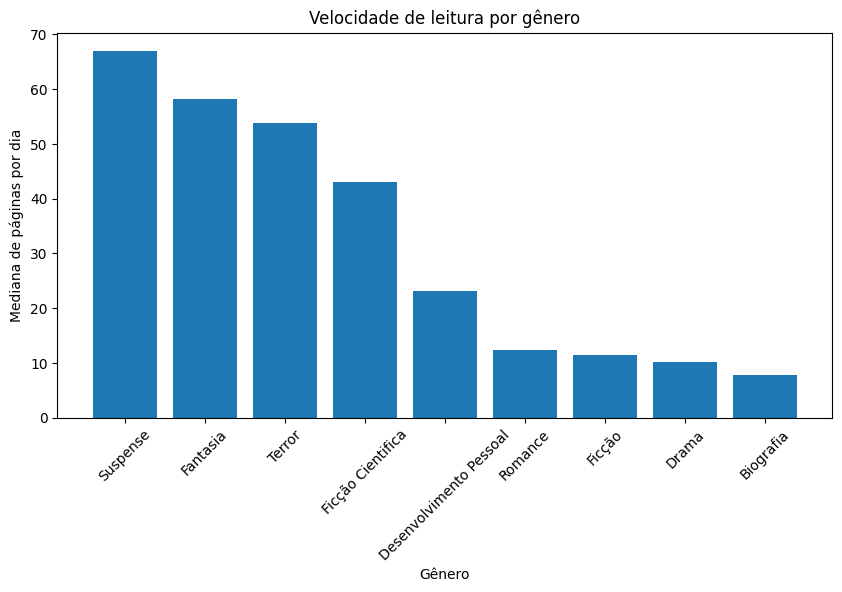

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(velocidade_genero.index, velocidade_genero.values)

plt.xlabel("Gênero")
plt.xticks(rotation=45)
plt.ylabel("Mediana de páginas por dia")
plt.title("Velocidade de leitura por gênero")

plt.show()

Conclusão: média de leitura, enquanto Biografia apresentou a menor. Entretanto, a diferença deve ser interpretada considerando a quantidade de livros de cada gênero

### Formato x velocidade de leitura

In [ ]:
df.groupby('formato')['paginas_por_dia'].agg(['count', 'mean', 'median'])

,count,mean,median
formato,,,
Ebook,40,59.774802,43.125000
Fisico,14,21.436067,14.498328


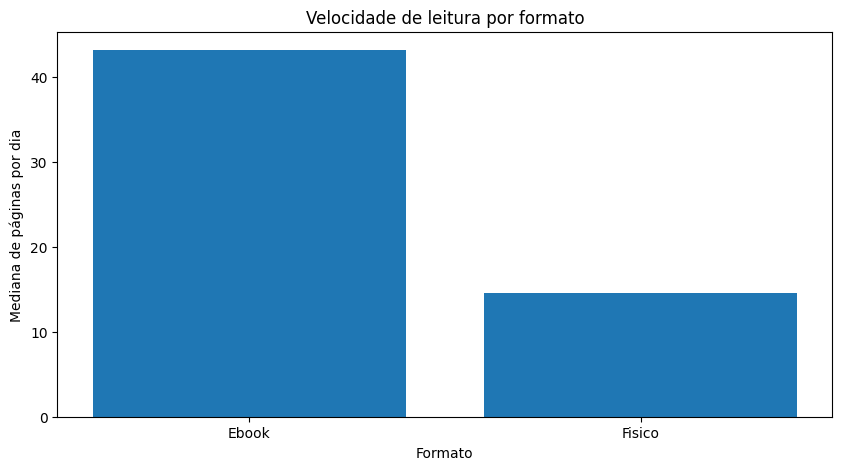

In [ ]:
velocidade_formato = df.groupby('formato')['paginas_por_dia'].median()

plt.figure(figsize=(10, 5))

plt.bar(velocidade_formato.index, velocidade_formato.values)

plt.xlabel("Formato")
plt.ylabel("Mediana de páginas por dia")
plt.title("Velocidade de leitura por formato")

plt.show()

Na amostra analisada, o formato digital apresentou uma velocidade de leitura significativamente maior que o formato físico. Entretanto, a diferença deve ser interpretada como uma associação observada nos dados, já que outros fatores podem influenciar o ritmo de leitura.

### **Conclusão**: O ritmo de leitura apresenta grande variação entre os livros, mas o tamanho da obra não se mostrou um fator relevante para determinar o tempo de conclusão ou a velocidade diária. Em contrapartida, foi observada uma diferença significativa de ritmo entre os formatos, com maior velocidade de leitura em e-books.

## 4 - Avaliações e preferências

### Avaliação média

In [ ]:
avaliacao_media = df['avaliacao'].mean()

print('A avaliação média foi de :', avaliacao_media.round(2))

A avaliação média foi de : 3.98


### Gênero x avaliação

In [ ]:
avaliacao_genero = df.groupby('genero')['avaliacao'].agg(['count', 'mean', 'median'])

print(avaliacao_genero)

                         count      mean  median
genero                                          
Biografia                    1  3.500000     3.5
Desenvolvimento Pessoal      4  4.125000     4.0
Drama                        1  3.500000     3.5
Fantasia                     6  4.250000     4.5
Ficção                       2  3.500000     3.5
Ficção Cientifica           14  4.178571     4.0
Romance                      1  3.500000     3.5
Suspense                    19  4.105263     4.0
Terror                       6  3.166667     3.0


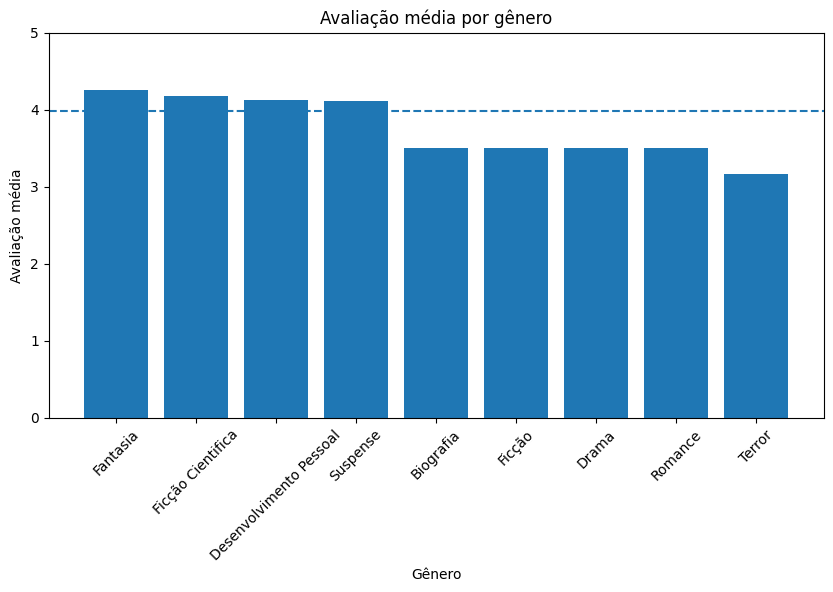

In [ ]:
avaliacao_genero = df.groupby('genero')['avaliacao'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(avaliacao_genero.index, avaliacao_genero.values)

plt.xlabel("Gênero")
plt.xticks(rotation=45)
plt.ylabel("Avaliação média")
plt.title("Avaliação média por gênero")

plt.axhline(
    y=df['avaliacao'].mean(),
    linestyle='--',
    label='Média geral'
)

plt.ylim(0, 5)

plt.show()

A avaliação média dos livros foi de 3,98/5. Entre os gêneros com maior quantidade de livros, Fantasia apresentou a maior avaliação média (4,25), seguida por Ficção Científica (4,18) e Suspense (4,11). Terror apresentou a menor média entre esses gêneros, com 3,17.

Os gêneros com poucos registros devem ser interpretados com cautela, pois uma quantidade reduzida de livros não é suficiente para representar uma preferência consolidada.

### Tamanho do livro x avaliação

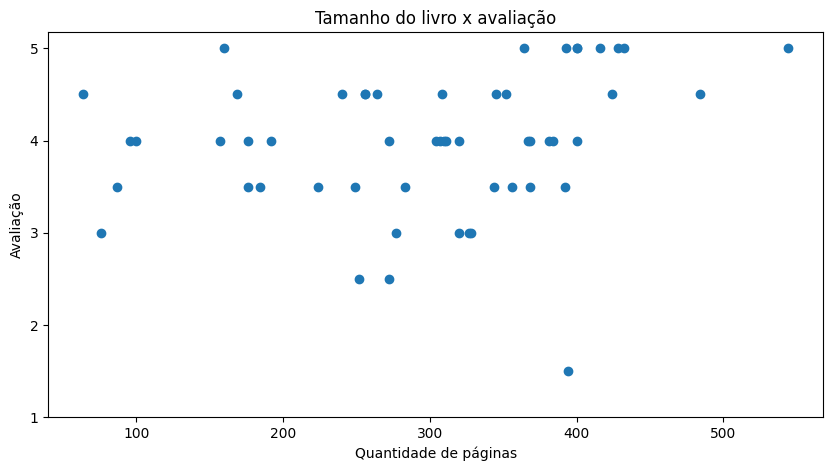

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(df['paginas'], df['avaliacao'])

plt.xlabel("Quantidade de páginas")
plt.ylabel("Avaliação")
plt.title("Tamanho do livro x avaliação")

plt.yticks([1, 2, 3, 4, 5])

plt.show()

In [ ]:
correlacao = df['paginas'].corr(df['avaliacao'])

print(f"Correlação: {correlacao:.2f}")

Correlação: 0.23


A análise apresentou uma correlação positiva fraca (0,23) entre o tamanho do livro e sua avaliação. Isso indica uma leve tendência de livros maiores receberem avaliações mais altas, porém a relação é pouco significativa na amostra analisada.

### Formato x avaliação

In [ ]:
avaliacao_formato = df.groupby('formato')['avaliacao'].agg(['count', 'mean', 'median'])

print(avaliacao_formato)

         count      mean  median
formato                         
Ebook       40  3.962500     4.0
Fisico      14  4.035714     4.0


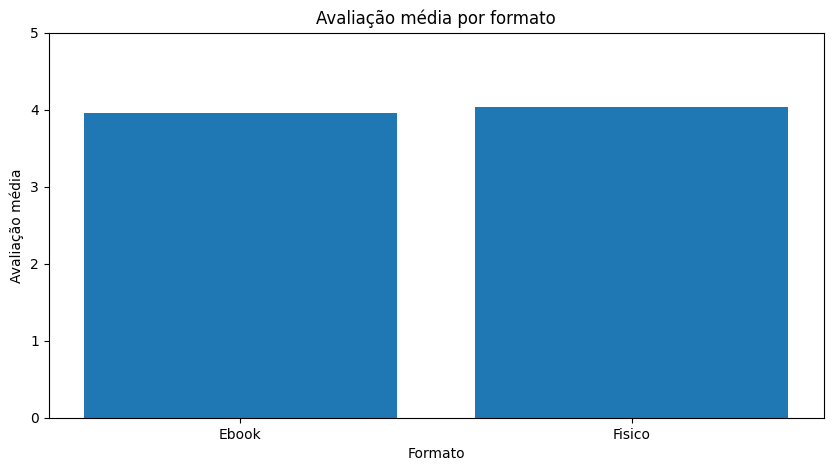

In [ ]:
avaliacao_formato = df.groupby('formato')['avaliacao'].mean()

plt.figure(figsize=(10, 5))

plt.bar(avaliacao_formato.index, avaliacao_formato.values)

plt.xlabel("Formato")
plt.ylabel("Avaliação média")
plt.title("Avaliação média por formato")

plt.ylim(0, 5)

plt.show()

A avaliação média foi semelhante entre os formatos, com 3,96 para e-books e 4,04 para livros físicos. Como a diferença é pequena e a mediana foi 4,0 em ambos, os dados indicam que o formato do livro não apresenta relação relevante com a avaliação atribuída.

### Evolução das avaliações

In [30]:
df.groupby(df['ano_leitura'])['avaliacao'].agg(['count', 'mean'])

,count,mean
ano_leitura,,
2016,1,4.000000
2017,1,4.000000
2018,2,3.250000
2019,1,4.000000
2020,3,4.333333
2021,9,4.333333
2022,3,4.500000
2024,7,4.214286
2025,14,3.821429


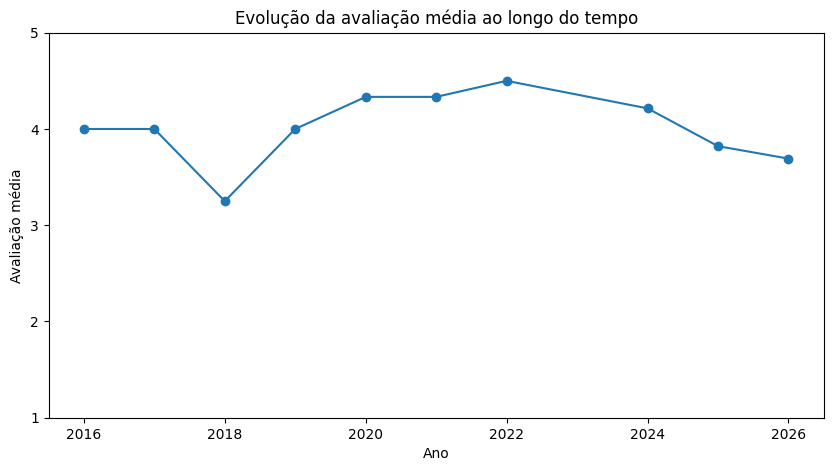

In [31]:
avaliacao_ano = df.groupby(df['ano_leitura'])['avaliacao'].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    avaliacao_ano.index,
    avaliacao_ano.values,
    marker='o'
)

plt.xlabel("Ano")
plt.ylabel("Avaliação média")
plt.title("Evolução da avaliação média ao longo do tempo")

plt.yticks([1, 2, 3, 4, 5])
plt.ylim(1, 5)

plt.show()

As avaliações apresentaram uma tendência de queda nos anos mais recentes. Após atingir uma média de 4,50 em 2022, a avaliação média caiu para 4,21 em 2024, 3,82 em 2025 e 3,69 em 2026. Esse resultado indica uma redução recente na avaliação atribuída aos livros, embora os primeiros anos tenham uma quantidade limitada de registros.

### Avaliações por gênero em cada ano

In [32]:
avaliacao_genero_ano = pd.pivot_table(
    df,
    values='avaliacao',
    index='genero',
    columns='ano_leitura',
    aggfunc='mean'
)

avaliacao_genero_ano

ano_leitura,2016,2017,2018,2019,2020,2021,2022,2024,2025,2026
genero,,,,,,,,,,
Biografia,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Desenvolvimento Pessoal,NaN,NaN,NaN,NaN,NaN,4.333333,NaN,NaN,NaN,3.500000
Drama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.50,NaN,NaN
Fantasia,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,4.50,4.000000,4.500000
Ficção,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,3.000000,NaN
Ficção Cientifica,4.0,4.0,3.0,4.0,4.5,4.000000,4.5,NaN,4.250000,4.250000
Romance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.500000,NaN
Suspense,NaN,NaN,NaN,NaN,NaN,4.500000,NaN,4.25,4.200000,3.666667
Terror,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.166667,3.166667


In [ ]:
participacao_genero = pd.crosstab(
    df['ano'],
    df['genero'],
    normalize='index'
) * 100

participacao_genero

genero,Biografia,Desenvolvimento Pessoal,Drama,Fantasia,Ficção,Ficção Cientifica,Romance,Suspense,Terror
ano,,,,,,,,,
2016,0.0,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000
2017,0.0,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000
2018,50.0,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000
2019,0.0,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000
2020,0.0,0.000000,0.000000,0.000000,33.333333,66.666667,0.000000,0.000000,0.000000
2021,0.0,33.333333,0.000000,11.111111,0.000000,11.111111,0.000000,44.444444,0.000000
2022,0.0,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000
2024,0.0,0.000000,14.285714,28.571429,0.000000,0.000000,0.000000,57.142857,0.000000
2025,0.0,0.000000,0.000000,14.285714,7.142857,14.285714,7.142857,35.714286,21.428571


In [ ]:
media_genero = df.groupby('genero')['avaliacao'].mean()

resultado = {}

for ano in [2024, 2025, 2026]:
    participacao = (
        df[df['ano'] == ano]['genero']
        .value_counts(normalize=True)
    )

    media_ponderada = sum(
        participacao[g] * media_genero[g]
        for g in participacao.index
    )

    resultado[ano] = media_ponderada

resultado

{2024: np.float64(4.060150375939849),
 2025: np.float64(3.8488184747583247),
 2026: np.float64(3.9125939849624065)}

In [ ]:
participacao_genero.loc[[2024, 2025, 2026]].T.sort_values(
    by=2026,
    ascending=False
)

ano,2024,2025,2026
genero,,,
Suspense,57.142857,35.714286,46.153846
Terror,0.000000,21.428571,23.076923
Ficção Cientifica,0.000000,14.285714,15.384615
Fantasia,28.571429,14.285714,7.692308
Desenvolvimento Pessoal,0.000000,0.000000,7.692308
Biografia,0.000000,0.000000,0.000000
Drama,14.285714,0.000000,0.000000
Ficção,0.000000,7.142857,0.000000
Romance,0.000000,7.142857,0.000000


A mudança no perfil dos gêneros contribuiu para a queda das avaliações em 2025, principalmente devido ao aumento da participação de gêneros com menor avaliação histórica. Entretanto, em 2026, a composição das leituras não explica a redução da média. Isso indica que a queda recente está também relacionada às avaliações atribuídas dentro dos próprios gêneros.

### **Conclusão**: As avaliações apresentam pouca relação com características físicas dos livros, como tamanho e formato, sendo mais influenciadas pelo gênero e pelo período de leitura. Embora a mudança no perfil dos gêneros tenha contribuído para a queda das avaliações em 2025, a redução observada em 2026 permanece mesmo após considerar essa mudança, indicando uma alteração mais recente no padrão de avaliação.

## 5- Insights finais

### **Leitura em crescimento**

**O volume e o ritmo de leitura aumentaram principalmente a partir de 2024**, com 2025 se destacando em quantidade de livros e 2026 em páginas lidas.

### **E-book acelera meu ritmo**

**43,1 pág./dia no e-book vs. 14,5 pág./dia no físico**, mas o formato praticamente não altera minha avaliação dos livros.

### **Tamanho não determina meu ritmo**

A correlação entre páginas e tempo de leitura foi de apenas **-0,07**, indicando que livros maiores não necessariamente levam mais tempo para serem concluídos.

### **Minha preferência está concentrada**

**Suspense e Ficção Científica** são os gêneros mais lidos, enquanto **Fantasia, Ficção Científica e Suspense** estão entre os gêneros com melhores avaliações.

### **Minhas avaliações estão caindo**

A média passou de **4,21 em 2024 → 3,82 em 2025 → 3,69 em 2026**. A mudança de gêneros explica parte da queda de 2025, mas** não explica a queda de 2026.**

## Limitações
 - apenas 54 livros
 - dados pessoais
 - período relativamente curto
 - 2026 ainda não terminou
 - tempo de leitura baseado em início/fim
 - algumas categorias possuem poucos registros.